In [1]:
import matplotlib.pyplot as plt
#For latex documents
#textwidth = 13
textwidth=12
figheight = 0.43*textwidth

plt.rc('figure', figsize=(0.48*textwidth,figheight))
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle="--")
plt.rc('grid', alpha="0.5")
plt.rc('axes', grid=True)

def latex_float(f):
    float_str = "{0:.2g}".format(f)
    if "e" in float_str:
        base, exponent = float_str.split("e")
        if(base == "1"):
            return r"10^{{{1}}}".format(base, int(exponent))
        return r"{0} \times 10^{{{1}}}".format(base, int(exponent))
    else:
        return float_str

import numpy as np
import re
from matplotlib.ticker import FormatStrFormatter

!mkdir fig

mkdir: cannot create directory ‘fig’: File exists


In [2]:
#grep -r "time :" **/log.out
def read_data(filename):
    dyablo_times={}
    for line in open(filename):
        print(line)
        test_size, block_size, nnodes, nmpi, amr_freq, group_size, timer_name, time  = re.match(".*run_([\d]*)_([\d]*)x[\d]*_([\d]*)nodesx([\d]*)mpi_amr([\d]*)_group([\d]*)/log.out:\s*(.*\S)\s*time : (\d*.\d*) .*", line).groups()
        key = (int(test_size), block_size, int(nnodes), int(nmpi), amr_freq, group_size, timer_name)
        dyablo_times[key] = float(time)
        print(key,time)
    return dyablo_times
data_cpu_raw = read_data("res_29-01-2021/cpu.timers")
data_gpu_raw = read_data("res_29-01-2021/gpu.timers")
print(data_cpu_raw)
print(data_gpu_raw)

bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:total       time : 418.637 secondes

(1024, '16', 1, 10, '1', '128', 'total') 418.637
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:godunov     time : 265.668 secondes 63.46%

(1024, '16', 1, 10, '1', '128', 'godunov') 265.668
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:compute dt  time : 5.899 secondes  1.41%

(1024, '16', 1, 10, '1', '128', 'compute dt') 5.899
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:boundaries  time : 0.000 secondes  0.00%

(1024, '16', 1, 10, '1', '128', 'boundaries') 0.000
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:io          time : 4.119 secondes  0.98%

(1024, '16', 1, 10, '1', '128', 'io') 4.119
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:block copy  time : 24.234 secondes  5.79%

(1024, '16', 1, 10, '1', '128', 'block copy') 24.234
bench/run_1024_16x16_1nodesx10mpi_amr1_group128/log.out:amr cycle   time : 105.741 secondes 25.26%

(1024, '16', 

In [3]:
timers = ["godunov","amr cycle","total"]
timer_total = "total"

sizes = [1024]
block_sizes = ["4","8","16","32"]
ngpus = [1]
amr_type = [1]

time_ramses = 537.9
time_godunov_ramses = 256.3

In [4]:
def print_times(data):  
    def print_line(ts):
        for t in ts:
            print( " | ", t, end="")
        print(" |")
    print_line(["Problem size", "block size", "nodes", "mpi/node", "AMR freq", "Group", timers[0] + " (s)", timers[1] + " (s)", "Total (s)" ])
    print_line(["-----", "-----", "-----", "-----", "-----", "-----", "-----", "-----", "-----"]);
    for (test_size, block_size, nnodes, nmpi, amr_freq, group_size, timer_name) in data.keys():
        if(timer_name == timers[0] ):
            time_total = data[(test_size, block_size, nnodes, nmpi, amr_freq, group_size, timer_total)];
            time_t0 = data[(test_size, block_size, nnodes, nmpi, amr_freq, group_size, timers[0])];
            time_t1 = data[(test_size, block_size, nnodes, nmpi, amr_freq, group_size, timers[1])];
            print_line([test_size, block_size, nnodes, nmpi, amr_freq, group_size, time_t0, time_t1, time_total]);
        
    
print_times(data_cpu_raw)
print()
print_times(data_gpu_raw)

 |  Problem size |  block size |  nodes |  mpi/node |  AMR freq |  Group |  godunov (s) |  amr cycle (s) |  Total (s) |
 |  ----- |  ----- |  ----- |  ----- |  ----- |  ----- |  ----- |  ----- |  ----- |
 |  1024 |  16 |  1 |  10 |  1 |  128 |  265.668 |  105.741 |  418.637 |
 |  1024 |  16 |  1 |  1 |  1 |  128 |  375.596 |  92.942 |  521.317 |
 |  1024 |  16 |  1 |  20 |  1 |  128 |  307.482 |  258.963 |  626.36 |
 |  1024 |  16 |  1 |  4 |  1 |  128 |  271.502 |  70.052 |  381.977 |
 |  1024 |  16 |  1 |  8 |  1 |  128 |  248.344 |  62.703 |  348.842 |
 |  1024 |  16 |  2 |  8 |  1 |  128 |  130.573 |  96.296 |  253.476 |
 |  1024 |  4 |  1 |  10 |  1 |  512 |  161.371 |  252.313 |  495.553 |
 |  1024 |  4 |  1 |  1 |  1 |  512 |  200.967 |  1237.288 |  1804.29 |
 |  1024 |  4 |  1 |  20 |  1 |  512 |  155.215 |  235.934 |  463.836 |
 |  1024 |  4 |  1 |  2 |  1 |  512 |  241.269 |  1045.834 |  1468.453 |
 |  1024 |  4 |  1 |  40 |  1 |  512 |  138.832 |  198.854 |  407.607 |
 |  10

In [5]:
def clean(data):
    res = {}
    for (s,bs,N,n,f,g,name) in data.keys():
        if name in timers :
            nk = (int(bs),N,n,name,int(f))
            res[nk] = min( data[(s,bs,N,n,f,g,name)], res.get( (bs,N,n,name), 999999 ) )
    return res
        
data_cpu = clean(data_cpu_raw)
data_gpu = clean(data_gpu_raw)

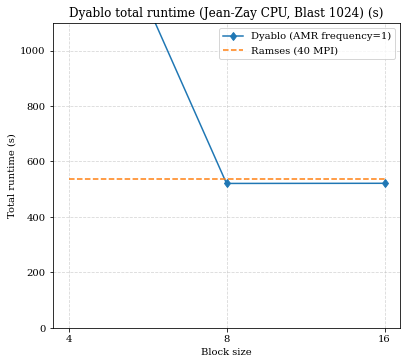

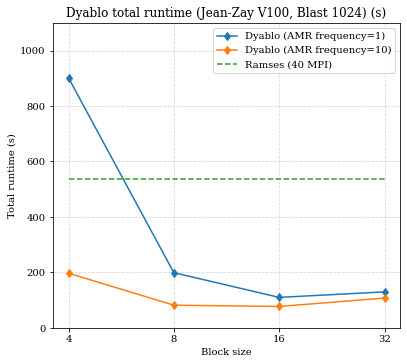

In [6]:

def flter( data, bs, N, n, tn, f=1 ):
    gen = filter( lambda k :   (bs==-1 or k[0]==bs) \
                            and (N==-1  or k[1]==N) \
                            and (n==-1  or k[2]==n) \
                            and (tn==""  or k[3]==tn) \
                            and (f==-1  or k[4]==f) \
                   , data )
    return [k for k in gen];

def plot_times_1mpi(data, label):   
    for f in 1, 10:
        interesting_keys = flter(data,-1,1,1,timer_total,f)
        if(len(interesting_keys)==0): continue
        block_sizes = [bs for (bs,N,n,tn,f) in interesting_keys]
        time_total = [data[k] for k in interesting_keys]
        block_sizes, time_total = zip(*sorted(zip(block_sizes, time_total)))     
        plt.plot(block_sizes, time_total, "-d", label="Dyablo (AMR frequency="+str(f)+")" )
    
    plt.plot(block_sizes, [time_ramses]*len(block_sizes), "--", label="Ramses (40 MPI)" )
    plt.ylim([0,1100])
    plt.title("Dyablo total runtime (Jean-Zay "+label+", Blast 1024) (s)")
    plt.legend()
    plt.xscale("log", base=2)
    plt.xlabel("Block size")
    plt.ylabel("Total runtime (s)")
    plt.xticks(block_sizes, labels=[ str(b) for b in block_sizes] )
    plt.tight_layout()
    plt.savefig("fig/time_over_blocksize.png")
    plt.show()
    
plot_times_1mpi(data_cpu, "CPU")
plot_times_1mpi(data_gpu, "V100")

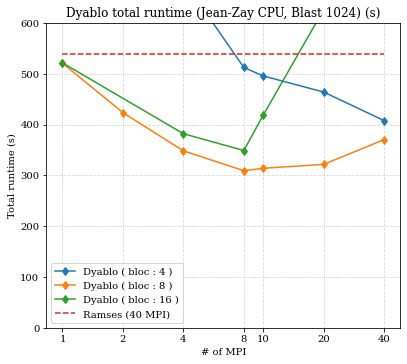

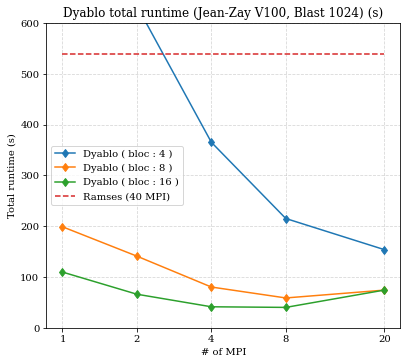

In [7]:
def plot_times_1node(data, label):
    mpi_max = 0
    all_mpi = {1}
    for bs in [4,8,16] :
        interesting_keys = flter(data,bs,1,-1,timer_total)
        mpi = [n for (bs,N,n,tn,f) in interesting_keys]
        mpi_max = max([mpi_max] + mpi )
        time_total = [data[k] for k in interesting_keys]    
        mpi, time_total = zip(*sorted(zip(mpi, time_total)))    
        plt.plot(mpi, time_total, "-d", label="Dyablo ( bloc : "+str(bs)+" )" )
        all_mpi.update(mpi)
    
    plt.plot([1,mpi_max], [time_ramses]*2, "--", label="Ramses (40 MPI)" )
    plt.ylim([0,600])
    
    plt.xscale("log", base=2)
    plt.title("Dyablo total runtime (Jean-Zay "+label+", Blast 1024) (s)")
    plt.legend()
    plt.xlabel("# of MPI")
    plt.ylabel("Total runtime (s)")
    plt.xticks(ticks=[m for m in all_mpi], labels=[str(m) for m in all_mpi])
    plt.tight_layout()
    plt.savefig("fig/time_over_mpi_1node_"+label+".png")
    plt.show()
    
plot_times_1node(data_cpu, "CPU" )
plot_times_1node(data_gpu, "V100")

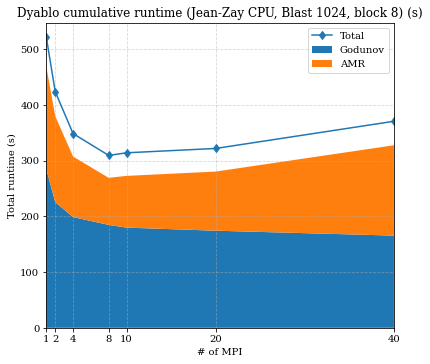

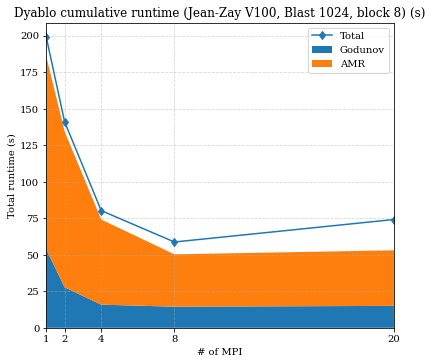

In [8]:
def plot_times_1node_8bloc(data, label):
    mpi_max = 1
    bs=8
    
    interesting_keys = flter(data,bs,1,-1,timer_total)
    mpi = [n for (bs,N,n,tn,f) in interesting_keys]
    mpi_max = max([mpi_max] + mpi )
    time_total = [data[k] for k in interesting_keys]
    
    time_amr = [data[(bs,N,n,"amr cycle",f)] for (bs,N,n,name,f) in interesting_keys]
    time_godunov = [data[(bs,N,n,"godunov",f)] for (bs,N,n,name,f) in interesting_keys]    

    mpi, time_total, time_amr, time_godunov = zip(*sorted(zip(mpi, time_total, time_amr, time_godunov)))   
    
    time_total = np.array(time_total)
    time_amr = np.array(time_amr)
    time_godunov = np.array(time_godunov)
    
    plt.fill_between(mpi, time_godunov, 0 , label="Godunov" ) 
    plt.fill_between(mpi, time_godunov, time_godunov+time_amr , label="AMR" )   
    plt.plot(mpi, time_total, "-d", label="Total" )         
    #plt.plot([1,mpi_max], [time_ramses]*2, "--", label="Ramses (40 MPI)" )
    plt.ylim(0)
    plt.xlim([1,mpi_max])
    plt.xticks(mpi)
    plt.title("Dyablo cumulative runtime (Jean-Zay "+label+", Blast 1024, block "+str(bs)+") (s)")
    plt.legend()
    plt.xlabel("# of MPI")
    plt.ylabel("Total runtime (s)")
    plt.tight_layout()
    plt.savefig("fig/time_over_blocksize.png")
    plt.show()
    
plot_times_1node_8bloc(data_cpu, "CPU")
plot_times_1node_8bloc(data_gpu, "V100")

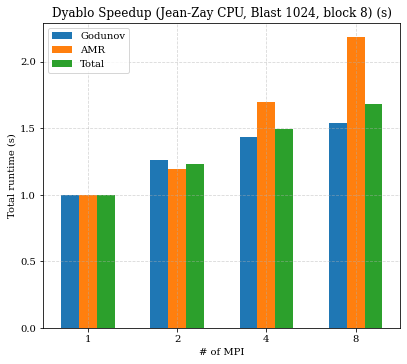

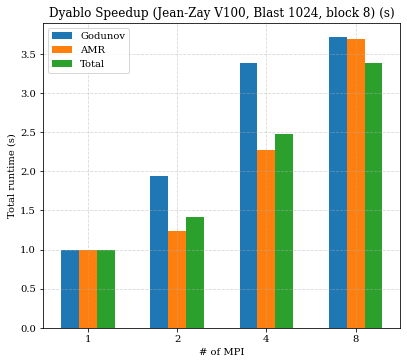

In [9]:
def plot_speedup_1node_8bloc(data, label):
    mpi_max = 1
    bs=8
    
    interesting_keys = flter(data,bs,1,-1,timer_total)
    mpi = [n for (bs,N,n,tn,f) in interesting_keys]
    mpi_max = max([mpi_max] + mpi )
    time_total = [data[k] for k in interesting_keys]
    
    time_amr = [data[(bs,N,n,"amr cycle",f)] for (bs,N,n,name,f) in interesting_keys]
    time_godunov = [data[(bs,N,n,"godunov",f)] for (bs,N,n,name,f) in interesting_keys]    

    mpi, time_total, time_amr, time_godunov = zip(*sorted(zip(mpi, time_total, time_amr, time_godunov)))   
    
    time_total = np.array(time_total)
    time_amr = np.array(time_amr)
    time_godunov = np.array(time_godunov)
    
    plt.bar( np.arange(len(mpi))-0.2, time_godunov[0]/time_godunov, width=0.2, label="Godunov")
    plt.bar( np.arange(len(mpi)), time_amr[0]/time_amr, width=0.2, label="AMR")
    plt.bar( np.arange(len(mpi))+0.2, time_total[0]/time_total, width=0.2, label="Total")
    #plt.fill_between(mpi, time_godunov, 0 , label="Godunov" ) 
    #plt.fill_between(mpi, time_godunov, time_godunov+time_amr , label="AMR" )   
    #plt.plot(mpi, time_total, "-d", label="Total" )         
    #plt.plot([1,mpi_max], [time_ramses]*2, "--", label="Ramses (40 MPI)" )
    plt.ylim(0)
    plt.xlim([-0.5,3.5])
    plt.xticks([0,1,2,3],[1,2,4,8])
    plt.title("Dyablo Speedup (Jean-Zay "+label+", Blast 1024, block "+str(bs)+") (s)")
    plt.legend()
    plt.xlabel("# of MPI")
    plt.ylabel("Total runtime (s)")
    plt.tight_layout()
    plt.savefig("fig/time_over_blocksize.png")
    plt.show()
    
plot_speedup_1node_8bloc(data_cpu, "CPU")
plot_speedup_1node_8bloc(data_gpu, "V100")

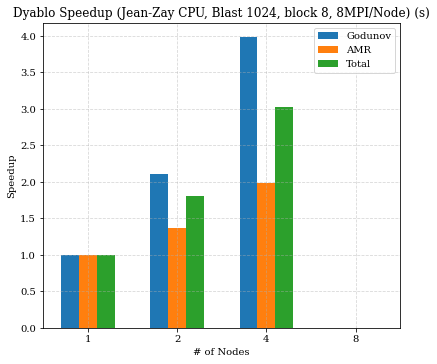

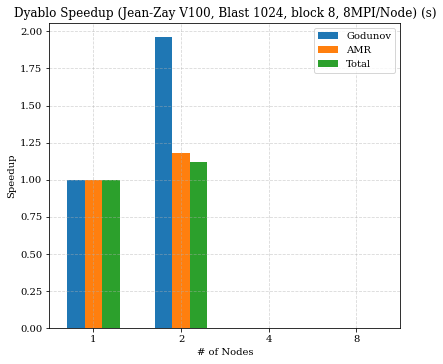

In [20]:
def plot_times_mpi(data, label):
    mpi_max = 1
    nb_threads = 8
    bs=8
    
    interesting_keys = flter(data,bs,-1,nb_threads,timer_total)
    mpi = [N for (bs,N,n,tn,f) in interesting_keys]
    mpi_max = max([mpi_max] + mpi )
    time_total = [data[k] for k in interesting_keys]
    
    time_amr = [data[(bs,N,n,"amr cycle",f)] for (bs,N,n,name,f) in interesting_keys]
    time_godunov = [data[(bs,N,n,"godunov",f)] for (bs,N,n,name,f) in interesting_keys]    

    mpi, time_total, time_amr, time_godunov = zip(*sorted(zip(mpi, time_total, time_amr, time_godunov)))   
    
    time_total = np.array(time_total)
    time_amr = np.array(time_amr)
    time_godunov = np.array(time_godunov)
    
    plt.bar( np.arange(len(mpi))-0.2, time_godunov[0]/time_godunov, width=0.2, label="Godunov")
    plt.bar( np.arange(len(mpi)), time_amr[0]/time_amr, width=0.2, label="AMR")
    plt.bar( np.arange(len(mpi))+0.2, time_total[0]/time_total, width=0.2, label="Total")
    #plt.fill_between(mpi, time_godunov, 0 , label="Godunov" ) 
    #plt.fill_between(mpi, time_godunov, time_godunov+time_amr , label="AMR" )   
    #plt.plot(mpi, time_total, "-d", label="Total" )         
    #plt.plot([1,mpi_max], [time_ramses]*2, "--", label="Ramses (40 MPI)" )
    plt.ylim(0)
    plt.xlim([-0.5,3.5])
    plt.xticks([0,1,2,3],[1,2,4,8])
    plt.title("Dyablo Speedup (Jean-Zay "+label+", Blast 1024, block "+str(bs)+", "+str(nb_threads)+"MPI/Node) (s)")
    plt.legend()
    plt.xlabel("# of Nodes")
    plt.ylabel("Speedup")
    plt.tight_layout()
    plt.savefig("fig/time_over_blocksize.png")
    plt.show()
    
plot_times_mpi(data_cpu, "CPU")
plot_times_mpi(data_gpu, "V100")